In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score


In [3]:
data = pd.read_csv("dataset1.csv")

In [4]:
print(data.shape)
print(data.columns)
print(data.info())
print(data.describe())

(10000, 34)
Index(['video_id', 'title', 'title_length', 'has_caps_title',
       'has_emoji_title', 'has_question_title', 'channel_name',
       'subscriber_count', 'channel_verified', 'category', 'publish_date',
       'trending_date', 'days_to_trend', 'year', 'month', 'day_of_week',
       'trending_country', 'language', 'duration_seconds', 'views', 'likes',
       'dislikes', 'comments', 'like_view_ratio_pct', 'comment_view_ratio_pct',
       'engagement_score', 'tags', 'tag_count', 'description_length',
       'has_links_description', 'clickbait_score', 'comments_enabled',
       'caption_available', 'made_for_kids'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 34 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   video_id                10000 non-null  object 
 1   title                   10000 non-null  object 
 2   title_length           

# loging

In [5]:
data['publish_date'] = pd.to_datetime(data['publish_date'])
data['publish_weekday'] = data['publish_date'].dt.dayofweek
data['publish_month'] = data['publish_date'].dt.month

# Feature Engineering

In [6]:
drop_cols = ['video_id', 'title', 'channel_name', 'publish_date', 
             'trending_date', 'day_of_week', 'language', 'tags']
data = data.drop(columns=drop_cols, errors='ignore')

data = data.replace([np.inf, -np.inf], np.nan).dropna()

data['trend_fast'] = (data['days_to_trend'] <= 3).astype(int)

# EDA

In [7]:
num_cols = [
    "views",
    "likes",
    "comments",
    "engagement_score",
    "like_view_ratio_pct",
    "comment_view_ratio_pct",
    "subscriber_count",
    "tag_count",
    "duration_seconds",
    "dislikes",
    "clickbait_score",
    "days_to_trend"
]

for col in num_cols:
    data[col] = pd.to_numeric(data[col], errors="coerce")

data = data.replace([np.inf, -np.inf], np.nan)
data = data.dropna(subset=num_cols)

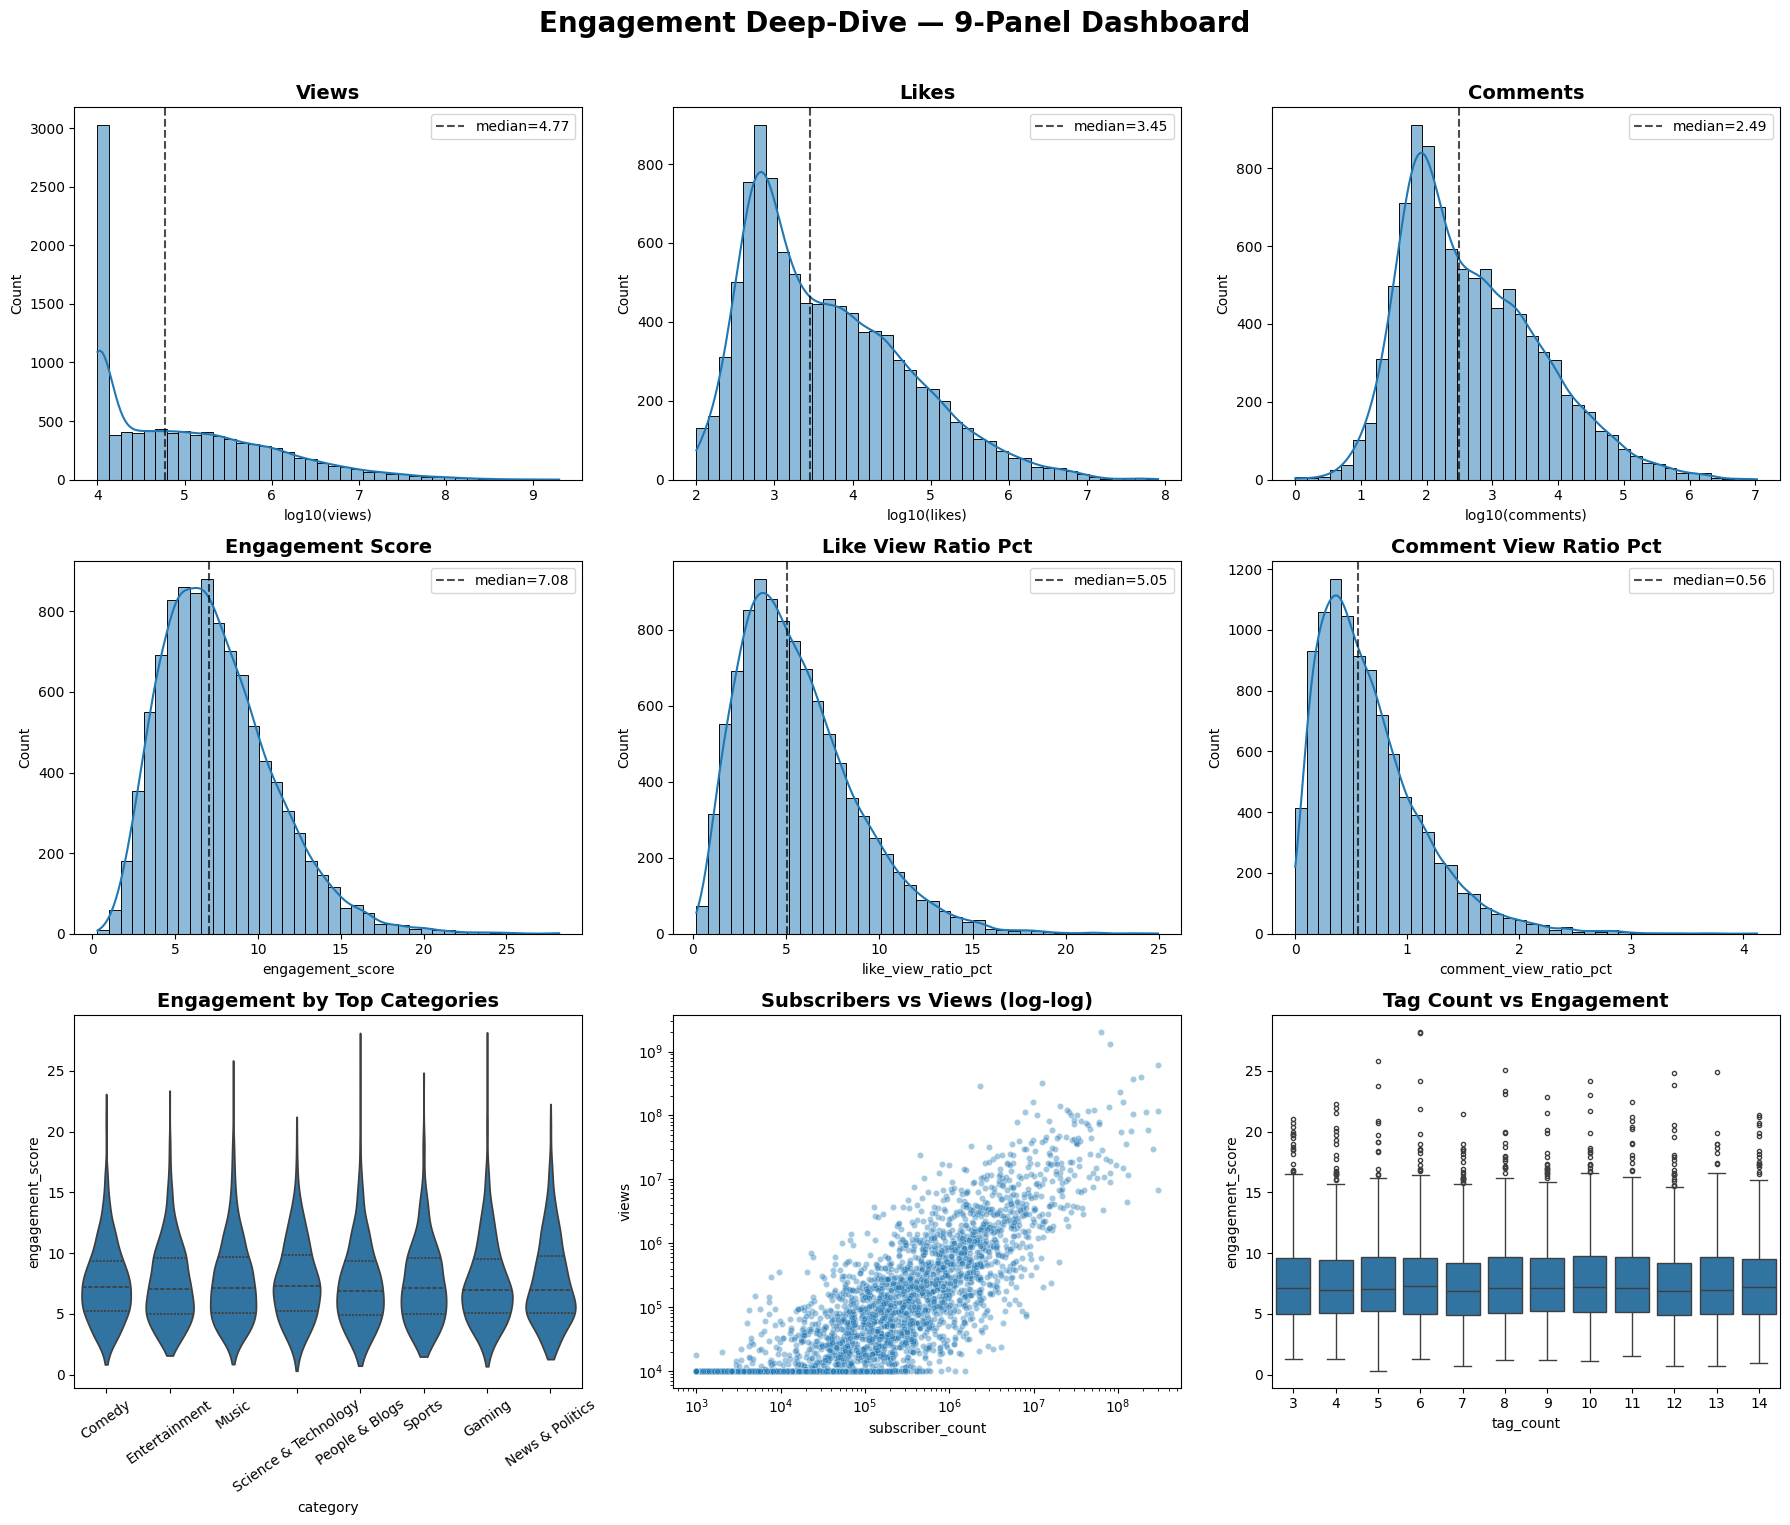

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(18, 16))
fig.suptitle("Engagement Deep-Dive — 9-Panel Dashboard", fontsize=20, fontweight='bold', y=0.98)

for i, col in enumerate(["views", "likes", "comments"]):
    log_data = np.log10(data[col].clip(lower=1))
    sns.histplot(log_data, bins=40, kde=True, ax=axes[0, i])
    median_val = log_data.median()
    axes[0, i].axvline(median_val, color='black', linestyle='--', alpha=0.7, 
                       label=f"median={median_val:.2f}")
    axes[0, i].set_title(col.capitalize(), fontsize=14, fontweight='bold')
    axes[0, i].set_xlabel(f"log10({col})")
    axes[0, i].legend()

for i, col in enumerate(["engagement_score", "like_view_ratio_pct", "comment_view_ratio_pct"]):
    sns.histplot(data[col], bins=40, kde=True, ax=axes[1, i])
    median_val = data[col].median()
    axes[1, i].axvline(median_val, color='black', linestyle='--', alpha=0.7, 
                       label=f"median={median_val:.2f}")
    axes[1, i].set_title(col.replace("_", " ").title(), fontsize=14, fontweight='bold')
    axes[1, i].set_xlabel(col)
    axes[1, i].legend()

top_cats = data["category"].value_counts().head(8).index
sns.violinplot(data=data[data["category"].isin(top_cats)], x="category", y="engagement_score", 
               ax=axes[2, 0], inner="quartile", cut=0)
axes[2, 0].set_title("Engagement by Top Categories", fontsize=14, fontweight='bold')
axes[2, 0].tick_params(axis='x', rotation=35)


sample_df = data.sample(min(len(data), 3000), random_state=42)
sns.scatterplot(data=sample_df, x="subscriber_count", y="views", ax=axes[2, 1], alpha=0.4, s=20)
axes[2, 1].set_xscale("log")
axes[2, 1].set_yscale("log")
axes[2, 1].set_title("Subscribers vs Views (log-log)", fontsize=14, fontweight='bold')

tag_filter = data[data["tag_count"].between(3, 14)]
sns.boxplot(data=tag_filter, x="tag_count", y="engagement_score", ax=axes[2, 2], fliersize=3)
axes[2, 2].set_title("Tag Count vs Engagement", fontsize=14, fontweight='bold')


plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

/var/folders/xz/jl0x7g45257404n2n3_cp3xh0000gn/T/ipykernel_3796/2304354451.py:144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


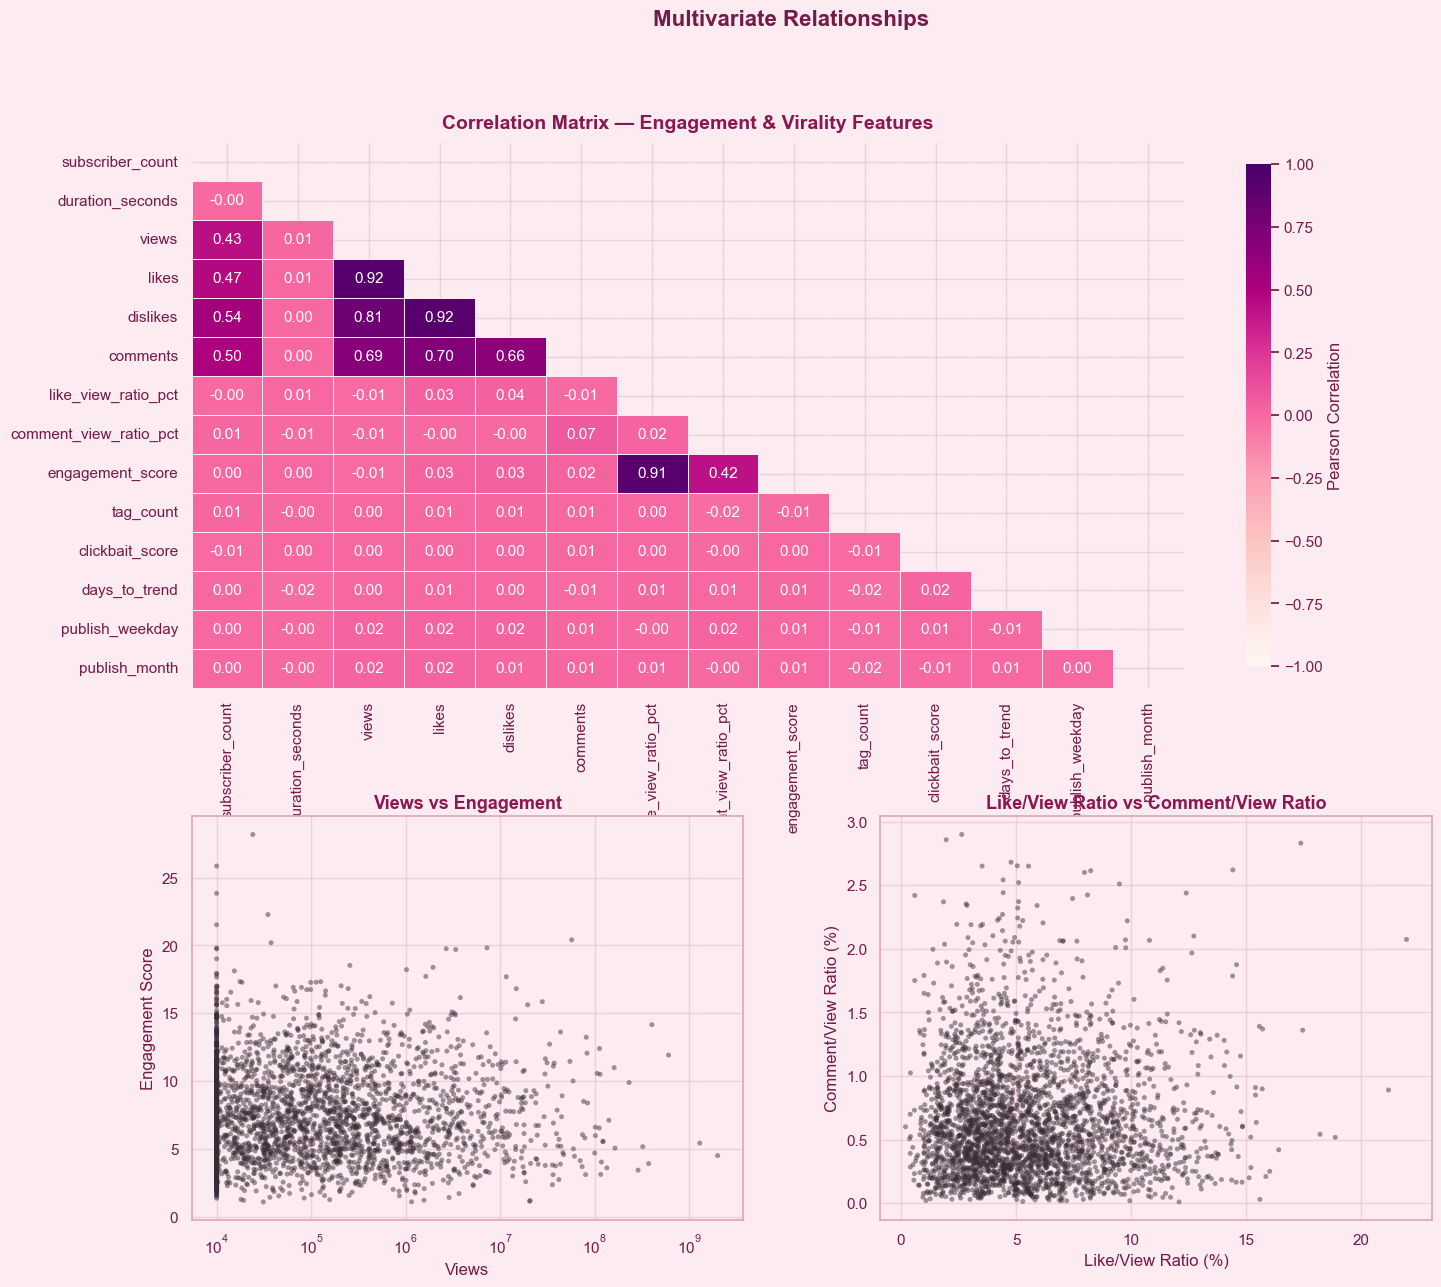

In [9]:

corr_cols = [
    "subscriber_count",
    "duration_seconds",
    "views",
    "likes",
    "dislikes",
    "comments",
    "like_view_ratio_pct",
    "comment_view_ratio_pct",
    "engagement_score",
    "tag_count",
    "clickbait_score",
    "days_to_trend",
    "publish_weekday",
    "publish_month",
    "publish_dayofyear",
    "like_comment_ratio",        
    "total_engagement_ratio",    
    "likes_per_second",      
    "comments_per_second",   
    "early_engagement"           
]

available_cols = [col for col in corr_cols if col in data.columns]
missing_cols = set(corr_cols) - set(data.columns)


corr_data = (
    data[available_cols]  
    .apply(pd.to_numeric, errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

corr = corr_data.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.set_theme(style="whitegrid")

plt.rcParams.update({
    "figure.facecolor": "#FCEBF1",
    "axes.facecolor": "#FCEBF1",
    "axes.edgecolor": "#DDA8BC",
    "axes.labelcolor": "#741B47",
    "axes.titlecolor": "#8A1750",
    "xtick.color": "#741B47",
    "ytick.color": "#741B47",
    "text.color": "#741B47",
    "grid.color": "#E6C2D0",
    "grid.alpha": 0.65,
    "font.size": 11
})

fig = plt.figure(figsize=(16, 14), facecolor="#FCEBF1")

gs = fig.add_gridspec(
    2, 2,
    height_ratios=[1.35, 1],
    hspace=0.27,
    wspace=0.25
)

ax_h = fig.add_subplot(gs[0, :])
ax_l = fig.add_subplot(gs[1, 0])
ax_r = fig.add_subplot(gs[1, 1])

sns.heatmap(
    corr,
    mask=mask,
    cmap="RdPu",
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.7,
    linecolor="#FCEBF1",
    square=False,
    cbar=True,
    cbar_kws={
        "label": "Pearson Correlation",
        "shrink": 0.92,
        "pad": 0.05
    },
    ax=ax_h
)

ax_h.set_title(
    "Correlation Matrix — Engagement & Virality Features",
    fontsize=14,
    fontweight="bold",
    pad=10
)

sample = corr_data.sample(
    min(3000, len(corr_data)),
    random_state=42
)

ax_l.scatter(
    sample["views"],
    sample["engagement_score"],
    color="#392B35",
    s=13,
    alpha=0.48,
    edgecolors="none"
)

ax_l.set_xscale("log")
ax_l.set_title("Views vs Engagement", fontsize=13, fontweight="bold")
ax_l.set_xlabel("Views")
ax_l.set_ylabel("Engagement Score")

ax_r.scatter(
    sample["like_view_ratio_pct"],
    sample["comment_view_ratio_pct"],
    color="#392B35",
    s=13,
    alpha=0.48,
    edgecolors="none"
)

ax_r.set_title(
    "Like/View Ratio vs Comment/View Ratio",
    fontsize=13,
    fontweight="bold"
)

ax_r.set_xlabel("Like/View Ratio (%)")
ax_r.set_ylabel("Comment/View Ratio (%)")

for ax in [ax_h, ax_l, ax_r]:
    for spine in ax.spines.values():
        spine.set_color("#DDA8BC")

fig.suptitle(
    "Multivariate Relationships",
    fontsize=16,
    fontweight="bold",
    color="#741B47",
    y=0.975
)

plt.tight_layout()

plt.savefig(
    "multivariate_relationships_pink.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="#FCEBF1"
)

plt.show()

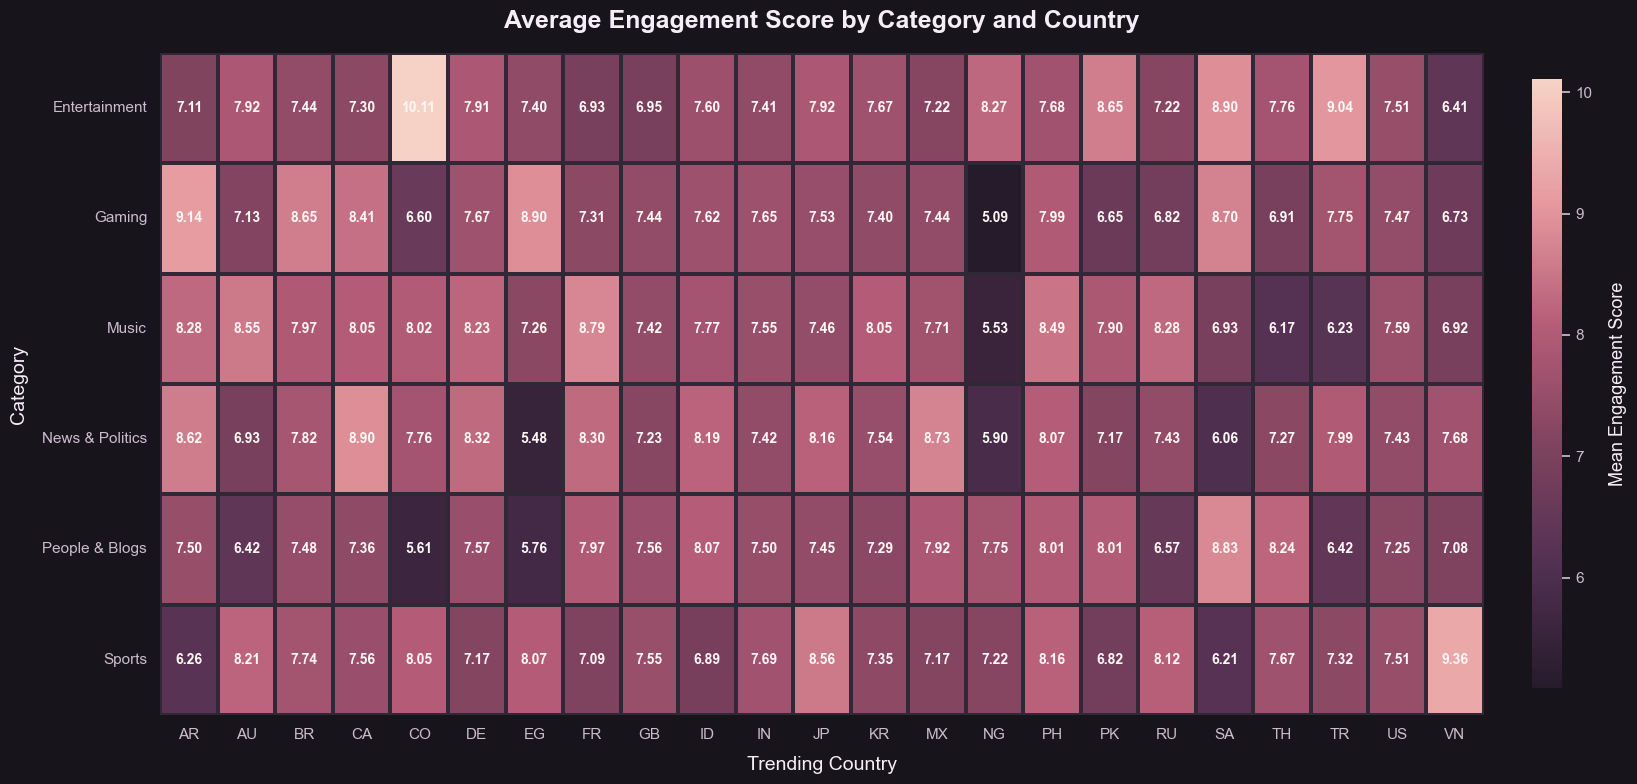

In [10]:
heatmap_data = (
    data.groupby(["category", "trending_country"])["engagement_score"]
    .mean()
    .unstack()
)


category_order = [
    "Entertainment", "Gaming", "Music", 
    "News & Politics", "People & Blogs", "Sports"
]

heatmap_data = heatmap_data.reindex(
    [x for x in category_order if x in heatmap_data.index]
)


bg, panel, text, muted, grid = "#17141C", "#211B28", "#F5EEF7", "#CBBCCC", "#302837"

plt.rcParams.update({
    "figure.facecolor": bg,
    "axes.facecolor": panel,
    "axes.labelcolor": text,
    "axes.titlecolor": text,
    "xtick.color": muted,
    "ytick.color": muted,
    "font.size": 12
})

cmap = sns.blend_palette(
    ["#261B2B", "#513052", "#80435F", "#B65D78", "#E69A9F", "#F6D2C6"],
    as_cmap=True
)

fig, ax = plt.subplots(figsize=(18, 8), facecolor=bg)

sns.heatmap(
    heatmap_data,
    cmap=cmap,
    annot=True,
    fmt=".2f",
    linewidths=1.6,
    linecolor=grid,
    cbar_kws={"label": "Mean Engagement Score", "shrink": 0.92, "pad": 0.03},
    annot_kws={"fontsize": 10, "fontweight": "bold", "color": "#FFF7F5"},
    ax=ax
)

ax.set_title("Average Engagement Score by Category and Country", fontsize=18, fontweight="bold", pad=18)
ax.set_xlabel("Trending Country", fontsize=14, labelpad=10)
ax.set_ylabel("Category", fontsize=14, labelpad=10)

ax.tick_params(axis="x", rotation=0)
ax.tick_params(axis="y", rotation=0)

for spine in ax.spines.values():
    spine.set_visible(False)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(colors=muted)
cbar.set_label("Mean Engagement Score", color=text, fontsize=13, labelpad=12)

plt.tight_layout()
plt.show()

# Feature Selection

In [11]:
features = [
    'subscriber_count', 'channel_verified',
    'duration_seconds', 'tag_count', 'title_length',
    'description_length', 'clickbait_score',
    'views', 'likes', 'comments', 'dislikes',
    'like_view_ratio_pct', 'comment_view_ratio_pct', 'engagement_score',
    'has_caps_title', 'has_emoji_title', 'has_question_title',
    'comments_enabled', 'caption_available', 'made_for_kids',
    'publish_weekday', 'publish_month'
]

x = data[features]
y = data['trend_fast']

# Train-Test Split


In [ ]:

from sklearn.model_selection import train_test_split

x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state=42)



scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# Model Initialization

In [ ]:
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    eval_metric='logloss'
)


model.fit(x_train, y_train)

accuracy = model.score(x_test, y_test)
print(accuracy)

0.735
